In [1]:
# Dependencies managed via requirements.txt
# pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import gradio as gr

In [3]:
from pathlib import Path

# Resolve dataset path robustly whether executed from FRANCE_DATASET or project root
DATASET_PATH = Path("household_power_consumption.csv")
if not DATASET_PATH.exists() and (Path("FRANCE_DATASET") / "household_power_consumption.csv").exists():
    DATASET_PATH = Path("FRANCE_DATASET") / "household_power_consumption.csv"

df = pd.read_csv(
    DATASET_PATH,
    sep=';',
    header=None
)

df

C:\Users\Dell\AppData\Local\Temp\ipykernel_26460\2238012558.py:8: DtypeWarning: Columns (0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000
...,...,...,...,...,...,...,...,...,...
2075255,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075256,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075257,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [4]:
print("Original dataset shape:", df.shape)

df.head()

Original dataset shape: (2075260, 9)


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [5]:
df.columns = [
    'Date',
    'Time',
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

print("Columns:")
print(df.columns.tolist())

df.head()

Columns:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075260 entries, 0 to 2075259
Data columns (total 9 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   Date                   str   
 1   Time                   str   
 2   Global_active_power    object
 3   Global_reactive_power  object
 4   Voltage                object
 5   Global_intensity       object
 6   Sub_metering_1         object
 7   Sub_metering_2         object
 8   Sub_metering_3         object
dtypes: object(7), str(2)
memory usage: 176.0+ MB


In [7]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2075260, 9)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2075260 entries, 0 to 2075259
Data columns (total 9 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   Date                   str   
 1   Time                   str   
 2   Global_active_power    object
 3   Global_reactive_power  object
 4   Voltage                object
 5   Global_intensity       object
 6   Sub_metering_1         object
 7   Sub_metering_2         object
 8   Sub_metering_3         object
dtypes: object(7), str(2)
memory usage: 176.0+ MB

Missing values:
Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [8]:
df.describe()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075260,2075260,2075260,2075260,2075260,2075260,2075260,2075260,2049281.0
unique,1443,1441,6535,897,5169,378,154,146,54.0
top,17/12/2006,17:24:00,?,0.000,?,1.000,0.000,0.000,0.0
freq,1440,1442,25979,472785,25979,169406,1840610,1408273,813979.0


In [9]:
df.isin(["?"]).sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3               0
dtype: int64

In [10]:
df = df.replace('?', np.nan)

print("Missing values after replacing '?':")
print(df.isnull().sum())

Missing values after replacing '?':
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [11]:
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [12]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

print(df[['Date', 'Time', 'Datetime']].head())

         Date      Time            Datetime
0        Date      Time                 NaT
1  16/12/2006  17:24:00 2006-12-16 17:24:00
2  16/12/2006  17:25:00 2006-12-16 17:25:00
3  16/12/2006  17:26:00 2006-12-16 17:26:00
4  16/12/2006  17:27:00 2006-12-16 17:27:00


In [13]:
df = df.dropna(
    subset=[
        'Datetime',
        'Global_active_power'
    ]
)

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (2049280, 10)


In [14]:
df = df.sort_values('Datetime')

df = df.reset_index(drop=True)

print(df[['Datetime', 'Global_active_power']].head())

             Datetime  Global_active_power
0 2006-12-16 17:24:00                4.216
1 2006-12-16 17:25:00                5.360
2 2006-12-16 17:26:00                5.374
3 2006-12-16 17:27:00                5.388
4 2006-12-16 17:28:00                3.666


In [15]:
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour'] = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)

print(
    df[
        [
            'Datetime',
            'Year',
            'Month',
            'Day',
            'Hour',
            'Minute',
            'DayOfWeek',
            'IsWeekend'
        ]
    ].head()
)

             Datetime  Year  Month  Day  Hour  Minute  DayOfWeek  IsWeekend
0 2006-12-16 17:24:00  2006     12   16    17      24          5          1
1 2006-12-16 17:25:00  2006     12   16    17      25          5          1
2 2006-12-16 17:26:00  2006     12   16    17      26          5          1
3 2006-12-16 17:27:00  2006     12   16    17      27          5          1
4 2006-12-16 17:28:00  2006     12   16    17      28          5          1


In [16]:
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["Month"] = df["Datetime"].dt.month
df["Weekday"] = df["Datetime"].dt.dayofweek

In [17]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend,Weekday
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16,17,24,5,1,5
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16,17,25,5,1,5
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16,17,26,5,1,5
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16,17,27,5,1,5
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16,17,28,5,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049275,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0,2010-11-26 20:58:00,2010,11,26,20,58,4,0,4
2049276,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0,2010-11-26 20:59:00,2010,11,26,20,59,4,0,4
2049277,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0,2010-11-26 21:00:00,2010,11,26,21,0,4,0,4
2049278,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0,2010-11-26 21:01:00,2010,11,26,21,1,4,0,4


In [18]:
X = df[
    [
        "Voltage",
        "Global_reactive_power",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3",
        "Hour",
        "Day",
        "Month",
        "Weekday"
    ]
]

y = df["Global_active_power"]

In [19]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend,Weekday
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16,17,24,5,1,5
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16,17,25,5,1,5
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16,17,26,5,1,5
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16,17,27,5,1,5
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16,17,28,5,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049275,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0,2010-11-26 20:58:00,2010,11,26,20,58,4,0,4
2049276,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0,2010-11-26 20:59:00,2010,11,26,20,59,4,0,4
2049277,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0,2010-11-26 21:00:00,2010,11,26,21,0,4,0,4
2049278,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0,2010-11-26 21:01:00,2010,11,26,21,1,4,0,4


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred = model.predict(X_test)

In [23]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
0,1.502,1.543336
1,0.374,0.406717
2,0.620,0.659140
3,0.280,0.270706
4,1.372,1.371577
5,0.284,0.340285
6,0.196,0.198926
7,2.234,2.246312
8,0.486,0.492237
9,1.842,1.804151


In [24]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 0.025748312725233365
Mean Squared Error : 0.001620185454724765
Root Mean Squared Error : 0.04025152735890608
R2 Score : 0.9985584813820257


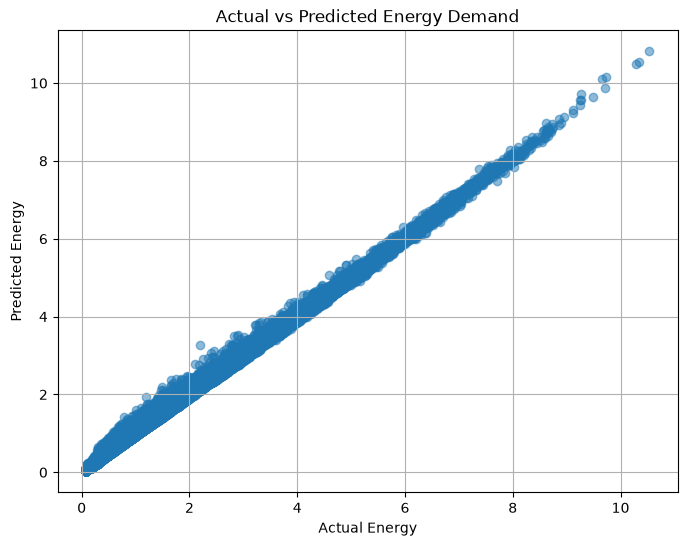

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Energy")

plt.ylabel("Predicted Energy")

plt.title("Actual vs Predicted Energy Demand")

plt.grid(True)

plt.show()

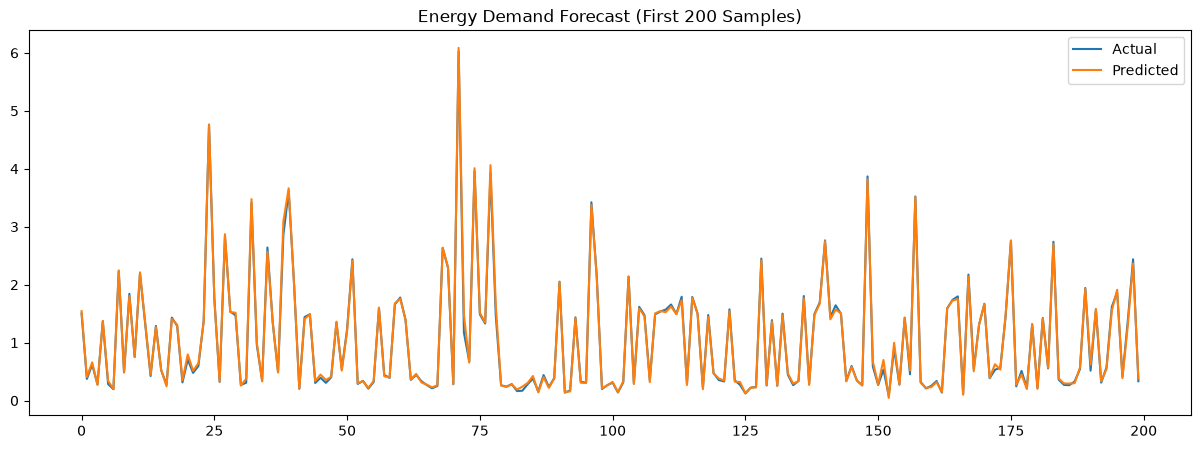

In [26]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values[:200], label="Actual")

plt.plot(y_pred[:200], label="Predicted")

plt.legend()

plt.title("Energy Demand Forecast (First 200 Samples)")

plt.show()

In [27]:
import joblib
from pathlib import Path

OUTPUT_DIR = Path("Linear_Regression_Output")
if not OUTPUT_DIR.exists() and (Path("FRANCE_DATASET") / "Linear_Regression_Output").exists():
    OUTPUT_DIR = Path("FRANCE_DATASET") / "Linear_Regression_Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "linear_regression_energy_model.pkl"
joblib.dump(model, MODEL_PATH)

print("Model Saved Successfully to", MODEL_PATH)


Model Saved Successfully to Linear_Regression_Output\linear_regression_energy_model.pkl
